# how scalable our_method is

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'scr')))

import numpy as np
import matplotlib.pyplot as plt
from TSCD_ancestor_search import *
from generate_LSEM import binary_code_array, generate_LSEM_samples_perfect
from utils import *
from metrics import *

In [ ]:
f1_list = []
run_time = []
import time
for n in range(50, 410, 10):
    n_nodes = n
    edge_prob = min(0.6, 6/(n-1))
    seed = np.random.randint(0, 1000)
    eps_var = np.random.uniform(0.01, 0.05, size=n_nodes)

    # eps_rvs = ['t5']*5 + ['gaussian']*5
    eps_rvs = None
    B = binary_code_array(n_nodes, observational=True)
    sample_sizes = [n**2] * B.shape[1]
    Lambda_true, X_list, perm, E, Lambdas = generate_LSEM_samples_perfect(
        n_nodes, edge_prob, sample_sizes, B,
        random_state=seed, eps_var=eps_var, eps_rvs=eps_rvs,
    )

    t0 = time.perf_counter()
    Lambda_est, node_permutation = TSCD_ancestor_search(
        X_list, B, n_candidates=3, pool_multiplier=5, threshold=0.2,
    )
    run_time.append(time.perf_counter() - t0)


    f1_list.append(f1_score(Lambda_est, Lambda_true))



In [ ]:
import pandas as pd

ns = list(range(50, 400, 10))
df = pd.DataFrame({
    "n_nodes": ns,
    "sample_size": [n**2 for n in ns],
    "runtime": run_time,
    "f1": f1_list,
})


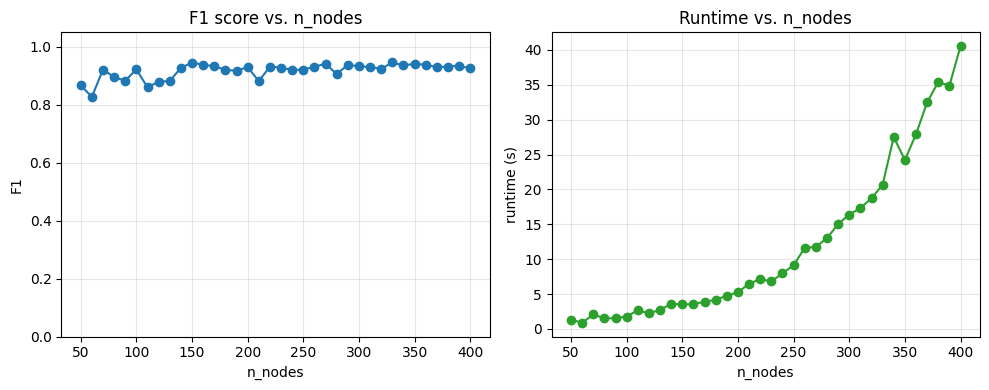

In [11]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(df.n_nodes, df['f1'], marker='o')
axes[0].set_xlabel('n_nodes')
axes[0].set_ylabel('F1')
axes[0].set_title('F1 score vs. n_nodes')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)


axes[1].plot(df.n_nodes, df.runtime, marker='o', color='C2')
axes[1].set_xlabel('n_nodes')
axes[1].set_ylabel('runtime (s)')
axes[1].set_title('Runtime vs. n_nodes')
# axes[1].set_yscale('log')
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()
